In [4]:
from utils.DataPreprocessing import dataloader
from loguru import logger
import os

path = os.path.dirname(os.path.dirname(os.getcwd()))
print(path)
data = dataloader(path=path)

2024-03-06 15:58:23.353 | INFO     | utils.DataPreprocessing:load_csv:123 - shape: (11_103, 3)
┌───────────┬─────────────┬────────────┐
│ AVG_TEMP  ┆ AVG_TEMP_DC ┆ date       │
│ ---       ┆ ---         ┆ ---        │
│ f32       ┆ str         ┆ date       │
╞═══════════╪═════════════╪════════════╡
│ 29.299999 ┆ C           ┆ 1992-07-01 │
│ 29.200001 ┆ C           ┆ 1992-07-02 │
│ 29.6      ┆ C           ┆ 1992-07-03 │
│ 29.299999 ┆ C           ┆ 1992-07-04 │
│ 29.299999 ┆ C           ┆ 1992-07-05 │
│ …         ┆ …           ┆ …          │
│ 22.200001 ┆ C           ┆ 2022-11-26 │
│ 22.4      ┆ C           ┆ 2022-11-27 │
│ 25.4      ┆ C           ┆ 2022-11-28 │
│ 25.1      ┆ C           ┆ 2022-11-29 │
│ 22.1      ┆ C           ┆ 2022-11-30 │
└───────────┴─────────────┴────────────┘
2024-03-06 15:58:23.354 | INFO     | utils.DataPreprocessing:load_csv:125 - shape: (1, 3)
┌──────────┬─────────────┬──────┐
│ AVG_TEMP ┆ AVG_TEMP_DC ┆ date │
│ ---      ┆ ---         ┆ ---  │
│ u32      ┆ u32

/home/argonaut/programming/Global-Solar-Radiation-in-King-s-Park


In [5]:
import polars as pl
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
import lightgbm as lgb
 
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
 
import warnings
warnings.filterwarnings('ignore')

In [6]:
#Building the RNN
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout

2024-03-06 15:58:23.876605: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-03-06 15:58:23.909954: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-03-06 15:58:23.909991: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-03-06 15:58:23.911940: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-03-06 15:58:23.916772: I tensorflow/core/platform/cpu_feature_guar

In [8]:
regressor = Sequential()

#Addinf the first LSTM layer and some Dropout regularisation
regressor.add(LSTM(units=50, return_sequences = True, input_shape=(data.X_train.shape[1], 1)))
regressor.add(Dropout(0.2))

regressor.add(LSTM(units=50, return_sequences = True))
regressor.add(Dropout(0.2))

regressor.add(LSTM(units=50, return_sequences = True))
regressor.add(Dropout(0.2))

regressor.add(LSTM(units=50))
regressor.add(Dropout(0.2))

#Output layer
regressor.add(Dense(units=1))

In [9]:
#Compiling
regressor.compile(optimizer='adam',loss='mean_squared_error')

In [10]:
from tensorflow.keras.callbacks import ModelCheckpoint,EarlyStopping
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import RootMeanSquaredError
from tensorflow.keras.optimizers import Adam

In [13]:
# Convert Polars DataFrame and Series to NumPy arrays
X_train = data.X_train.to_numpy()
y_train = data.y_train.to_numpy()
X_val = data.X_val.to_numpy()
y_val = data.y_val.to_numpy()

# Fit the model
history = regressor.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=100, batch_size=32)

Epoch 1/100
171/171 [==============================] - 11s 41ms/step - loss: 171.8857 - val_loss: 70.3335
Epoch 2/100
171/171 [==============================] - 6s 33ms/step - loss: 45.0872 - val_loss: 33.8406
Epoch 3/100
171/171 [==============================] - 6s 34ms/step - loss: 29.9651 - val_loss: 29.3766
Epoch 4/100
171/171 [==============================] - 6s 34ms/step - loss: 29.1929 - val_loss: 29.0536
Epoch 5/100
171/171 [==============================] - 6s 34ms/step - loss: 29.0412 - val_loss: 28.9807
Epoch 6/100
171/171 [==============================] - 6s 34ms/step - loss: 29.2440 - val_loss: 28.9712
Epoch 7/100
171/171 [==============================] - 6s 33ms/step - loss: 29.4761 - val_loss: 29.0391
Epoch 8/100
171/171 [==============================] - 6s 35ms/step - loss: 29.5475 - val_loss: 28.9748
Epoch 9/100
171/171 [==============================] - 6s 34ms/step - loss: 29.4148 - val_loss: 28.9937
Epoch 10/100
171/171 [==============================] - 6s 33m

In [16]:
X_test = data.X_test.to_numpy()
y_test = data.y_test.to_numpy().flatten()
test_pred = regressor.predict(X_test).flatten()


54/54 [==============================] - 1s 10ms/step


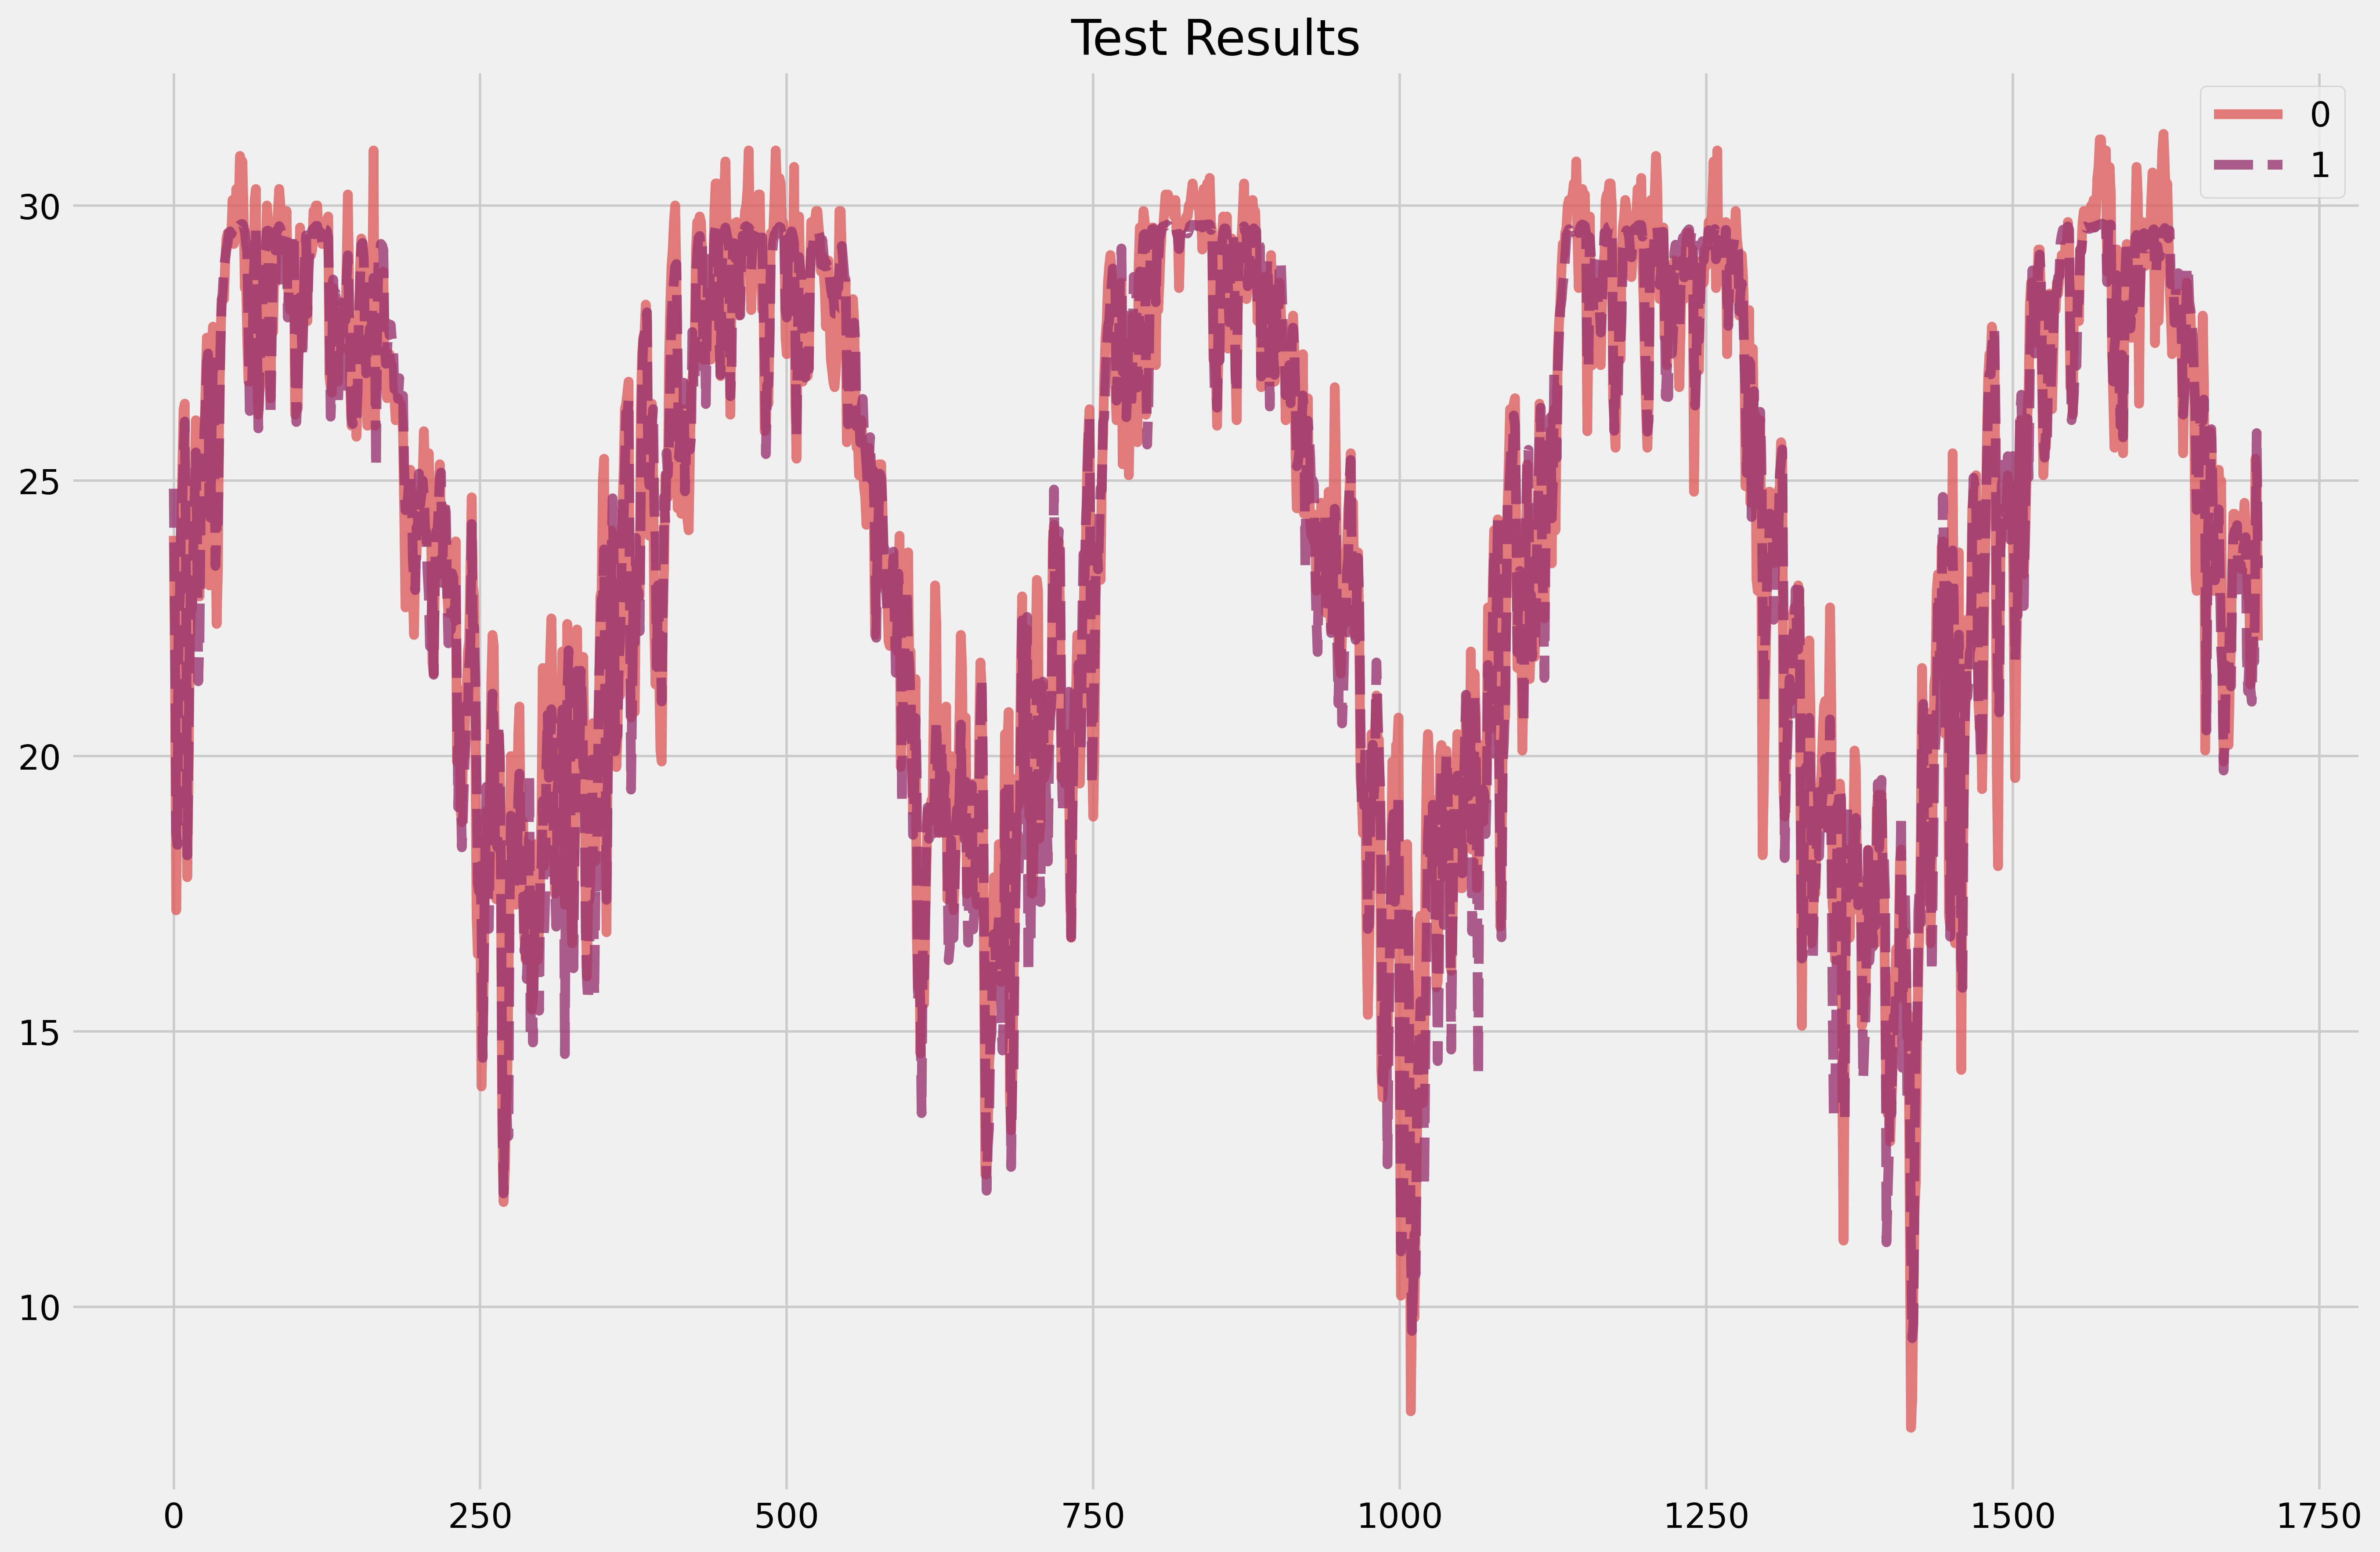

In [25]:

df_pred = pl.DataFrame({'actual': y_test,
                        'predicted': test_pred})

fig,axes = plt.subplots(1,1,figsize=(15,10),dpi=400)

# plt.subplot(2,1,2)
plt.title("Test Results")
sns.lineplot(df_pred,alpha=0.8,palette="flare",linestyle=None);

In [26]:
# calculate accuracy
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

mse = mean_squared_error(y_test, test_pred)
mae = mean_absolute_error(y_test, test_pred)
r2 = r2_score(y_test, test_pred)

logger.info(f"Mean Squared Error: {mse}")
logger.info(f"Mean Absolute Error: {mae}")
logger.info(f"R2 Score: {r2}")

2024-03-06 17:34:41.493 | INFO     | __main__:<module>:10 - Mean Squared Error: 0.9404770731925964
2024-03-06 17:34:41.494 | INFO     | __main__:<module>:11 - Mean Absolute Error: 0.7200832962989807
2024-03-06 17:34:41.494 | INFO     | __main__:<module>:12 - R2 Score: 0.9573475761090668
